In [22]:
import pandas as pd
import numpy as np

df = pd.read_csv("health_data/health_data.csv")

# Z-score calculation
systolic_bp = df["systolic_bp"].to_numpy()

mean_bp = np.mean(systolic_bp)
std_bp = np.std(systolic_bp)

z_scores = (systolic_bp - mean_bp) / std_bp

outliers = df[np.abs(z_scores) > 2]

print("Number of outliers:", len(outliers))
print("\nOutlier rows:")
print(outliers)

# Min-Max Normalisation
data = df[["exercise_hours_per_week",
           "sleep_hours_per_night"]].to_numpy()

mins = np.nanmin(data, axis=0)
maxs = np.nanmax(data, axis=0)

normalized = (data - mins) / (maxs - mins)

print("\nFirst 5 rows after normalisation:")
print(normalized[:5])

Number of outliers: 11

Outlier rows:
     age  gender smoker  height_cm  weight_kg  systolic_bp  diastolic_bp  \
3     64    Male    Yes      179.4       81.1        159.7          82.6   
20    59    Male    Yes      169.1       80.8        154.2          78.6   
52    57    Male     No      175.5       75.6        153.2          77.8   
83    28  Female     No      158.4       73.3        108.8          77.8   
85    45  Female    Yes      166.7       70.7        153.2          86.2   
119   22    Male     No      170.6       70.0        109.3          69.3   
135   51    Male    Yes      174.4       87.8        160.1          91.9   
149   63  Female    Yes      162.0       54.1        154.9          83.0   
166   27  Female     No      158.2       62.0        105.0          85.0   
185   23    Male     No      178.5       79.3        103.1          68.1   
192   22    Male     No      172.6       73.9        109.0          77.5   

     cholesterol  glucose  exercise_hours_per_wee

As dataset contains missing values.
Missing values = NaN.
nanmin() ignores them.

In [23]:
# Missing Values
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

print("Missing Values Summary:")
print(missing_summary[missing_summary["Missing Count"] > 0])

# Grouped Median Imputation
numeric_data = df.select_dtypes(include="number").columns

for data in numeric_data:
    if df[data].isnull().sum() > 0:
        df[data] = df[data].fillna(
            df.groupby("gender")[data].transform("median")
        )

# Verification
print("\nRemaining Missing Values:")
print(df.isnull().sum())

Missing Values Summary:
                         Missing Count  Missing Percentage
cholesterol                         12                 6.0
glucose                             10                 5.0
exercise_hours_per_week             14                 7.0
sleep_hours_per_night                8                 4.0

Remaining Missing Values:
age                        0
gender                     0
smoker                     0
height_cm                  0
weight_kg                  0
systolic_bp                0
diastolic_bp               0
cholesterol                0
glucose                    0
exercise_hours_per_week    0
sleep_hours_per_night      0
dtype: int64


df.groupby("gender") this creates groups: group 1 male, group 2 female
[col] select current column
.transform("median") calculate median of each group
fillna(...) fills NaN values with respective group median

/var/folders/vw/xrlnd6356jxclvs6th98stz00000gn/T/ipykernel_19918/3783746263.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(


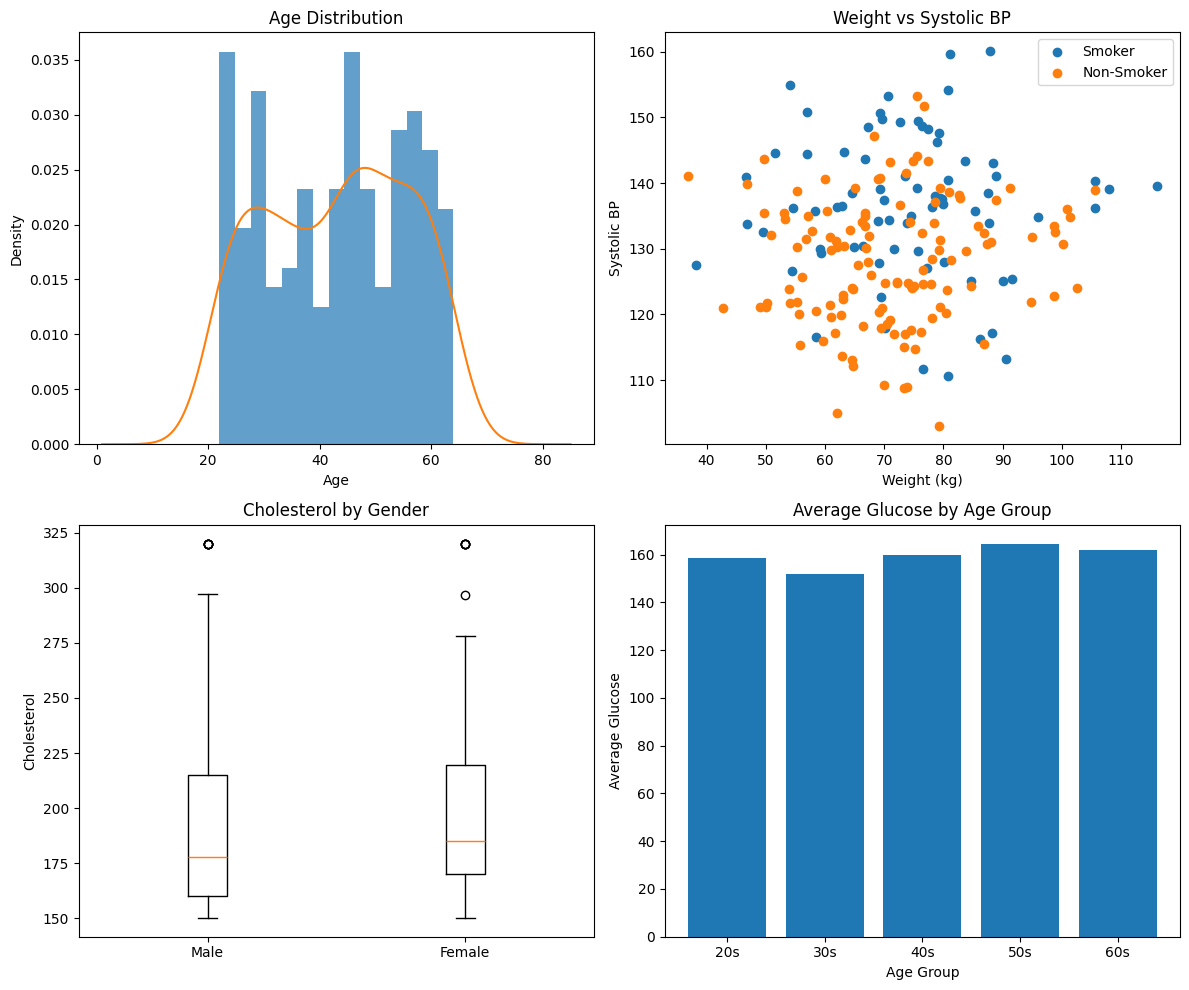

In [24]:
import matplotlib.pyplot as plt

# Create age groups
age_bins = [20, 30, 40, 50, 60, 70]
age_labels = ['20s', '30s', '40s', '50s', '60s']

df['age_group'] = pd.cut(
    df['age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

avg_glucose = df.groupby('age_group')['glucose'].mean()

# Create 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top Left: Histogram of Age + KDE
df['age'].plot(
    kind='hist',
    bins=15,
    density=True,
    alpha=0.7,
    ax=axes[0, 0]
)

df['age'].plot(
    kind='kde',
    ax=axes[0, 0]
)

axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Density')

# Top Right: Scatter Plot
smokers = df[df['smoker'] == 'Yes']
nonsmokers = df[df['smoker'] == 'No']

axes[0, 1].scatter(
    smokers['weight_kg'],
    smokers['systolic_bp'],
    label='Smoker'
)

axes[0, 1].scatter(
    nonsmokers['weight_kg'],
    nonsmokers['systolic_bp'],
    label='Non-Smoker'
)

axes[0, 1].set_title('Weight vs Systolic BP')
axes[0, 1].set_xlabel('Weight (kg)')
axes[0, 1].set_ylabel('Systolic BP')
axes[0, 1].legend()

# Bottom Left: Box Plot
male_chol = df[df['gender'] == 'Male']['cholesterol']
female_chol = df[df['gender'] == 'Female']['cholesterol']

axes[1, 0].boxplot(
    [male_chol, female_chol],
    labels=['Male', 'Female']
)

axes[1, 0].set_title('Cholesterol by Gender')
axes[1, 0].set_ylabel('Cholesterol')

# Bottom Right: Bar Chart
axes[1, 1].bar(
    avg_glucose.index.astype(str),
    avg_glucose.values
)

axes[1, 1].set_title('Average Glucose by Age Group')
axes[1, 1].set_xlabel('Age Group')
axes[1, 1].set_ylabel('Average Glucose')

plt.tight_layout()
plt.show()

df['age'] select age column
pd.cut() cuts continuous data into groups
Ages: 22 35 41 58 becomes 20s 30s 40s 50s
without right=False includes 30 in [20,30] with this range becomes 20 ≤ age < 30
